In [1]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = [15, 6]

Loaded 2220 images for class speed_30
Loaded 2250 images for class speed_50
Image 0 shape: (28, 28, 3)
Image 1 shape: (28, 28, 3)
Image 2 shape: (28, 28, 3)
Image 3 shape: (28, 28, 3)
Image 4 shape: (28, 28, 3)
Image 5 shape: (28, 28, 3)
Image 6 shape: (28, 28, 3)
Image 7 shape: (28, 28, 3)
Image 8 shape: (28, 28, 3)
Image 9 shape: (28, 28, 3)


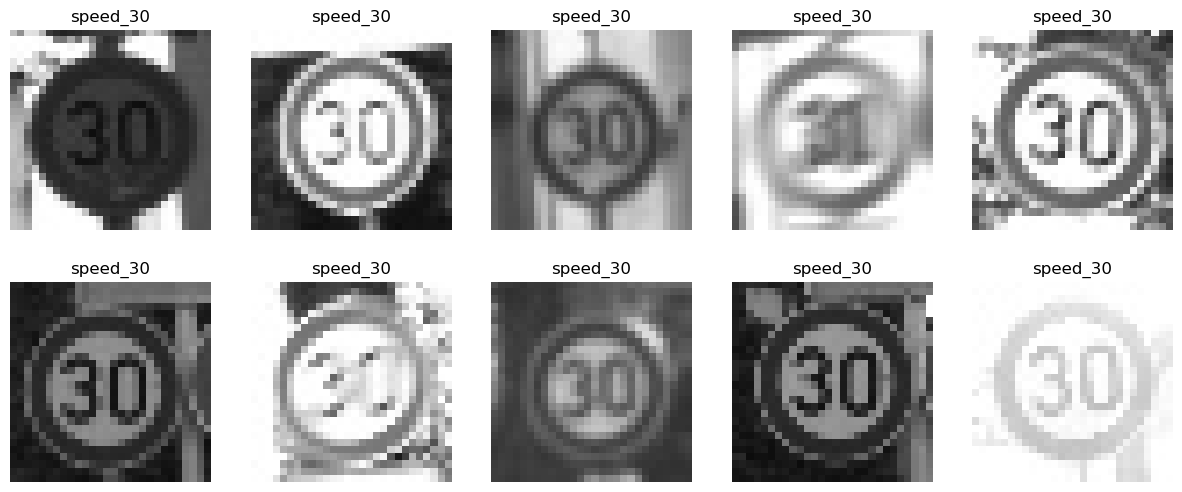

Image 0 shape: (28, 28, 3)
Image 1 shape: (28, 28, 3)
Image 2 shape: (28, 28, 3)
Image 3 shape: (28, 28, 3)
Image 4 shape: (28, 28, 3)
Image 5 shape: (28, 28, 3)
Image 6 shape: (28, 28, 3)
Image 7 shape: (28, 28, 3)
Image 8 shape: (28, 28, 3)
Image 9 shape: (28, 28, 3)


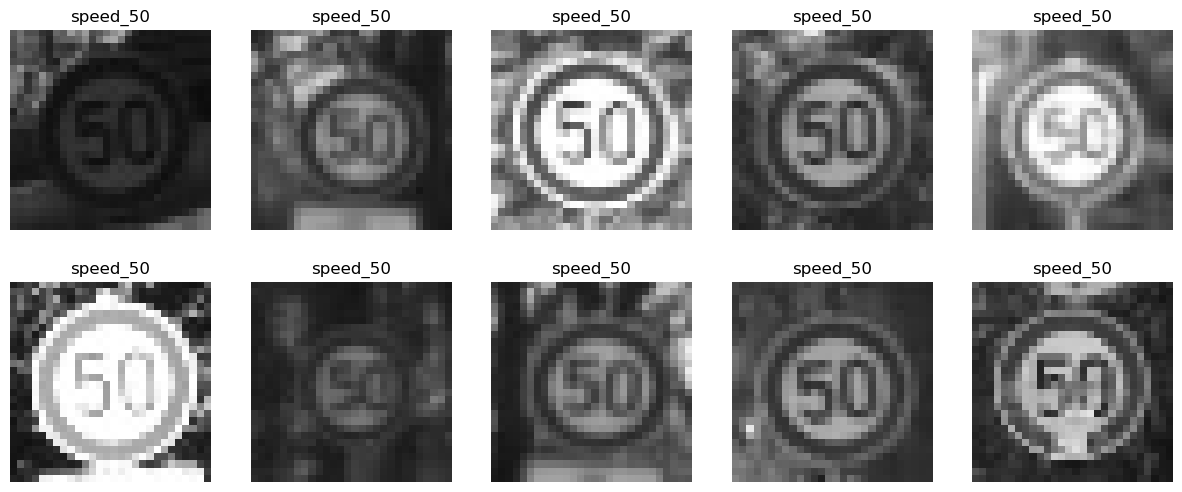

In [2]:
ClassData = tuple[list[str], list[np.ndarray], np.ndarray]

def load_image_class(class_name: str)-> ClassData:
    image_dir = os.path.join('data', class_name)
    image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')]
    images = [cv2.imread(f) for f in image_files]
    labels = np.array([class_name] * len(images))
    print(f'Loaded {len(images)} images for class {class_name}')
    return image_files, images, labels

def display_class_samples(class_data: ClassData):
    _, images, labels = class_data
    for i in range(min(10, len(images))):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(labels[i])
        plt.axis('off')
        print(f'Image {i} shape: {images[i].shape}')
    plt.show()

class_names = ['speed_30', 'speed_50']
class_data_list = [load_image_class(name) for name in class_names]
for class_data in class_data_list:
    display_class_samples(class_data)


In [3]:
images = np.concatenate([data[1] for data in class_data_list])
labels = np.concatenate([data[2] for data in class_data_list])
images, labels = shuffle(images, labels, random_state=42)
flatten_images = np.array([image.flatten() for image in images]) / 255
print(f'Total images: {len(images)}/{len(labels)}')
print(flatten_images.shape, flatten_images[0].shape, flatten_images[0].dtype)
print(f"Labels sample: {labels.shape}, {labels[:10]}")

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
print(f"Encoded labels sample: {encoded_labels.shape}, {encoded_labels[:10]}")


Total images: 4470/4470
(4470, 2352) (2352,) float64
Labels sample: (4470,), ['speed_50' 'speed_50' 'speed_30' 'speed_30' 'speed_30' 'speed_50'
 'speed_50' 'speed_30' 'speed_50' 'speed_50']
Encoded labels sample: (4470,), [1 1 0 0 0 1 1 0 1 1]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        23,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,541 (91.96 KB)

 Trainable params: 23,541 (91.96 KB)

 Non-trainable params: 0 (0.00 B)

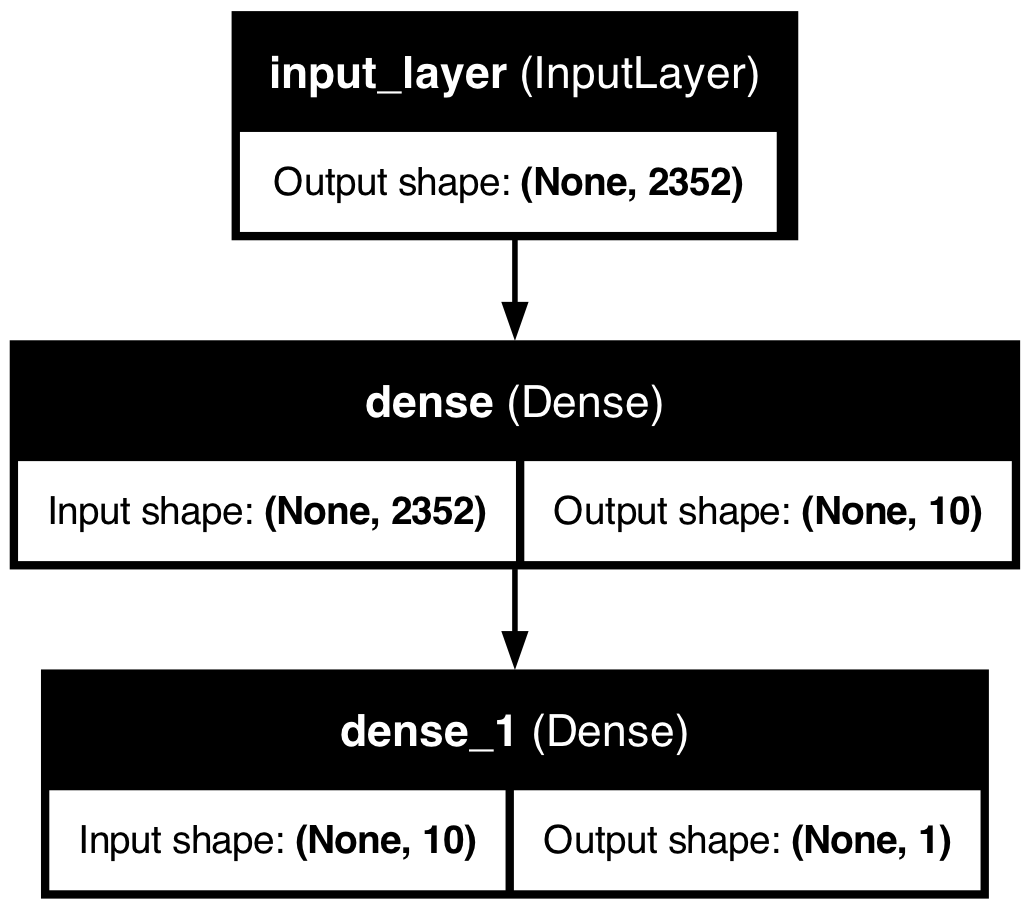

In [4]:
inputs = Input(shape=(flatten_images.shape[1],))
layer = Dense(10, activation="sigmoid")(inputs)
outputs = Dense(1, activation="sigmoid")(layer)
model = Model(inputs, outputs)

model.summary()
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

In [5]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')
history = model.fit(flatten_images, encoded_labels, epochs=20, batch_size=32, shuffle=False)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step - loss: 0.2418
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - loss: 0.2162
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - loss: 0.1903
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - loss: 0.1648
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - loss: 0.1415
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - loss: 0.1226
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - loss: 0.1085
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - loss: 0.0967
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - loss: 0.0866
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - loss: 0.0788
Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 0.0726
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - loss: 0.0675
Epoch 13/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - loss: 0.0634
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - loss: 0.0600
Epoch 15/20
140/140 ━━━━━━━━━

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

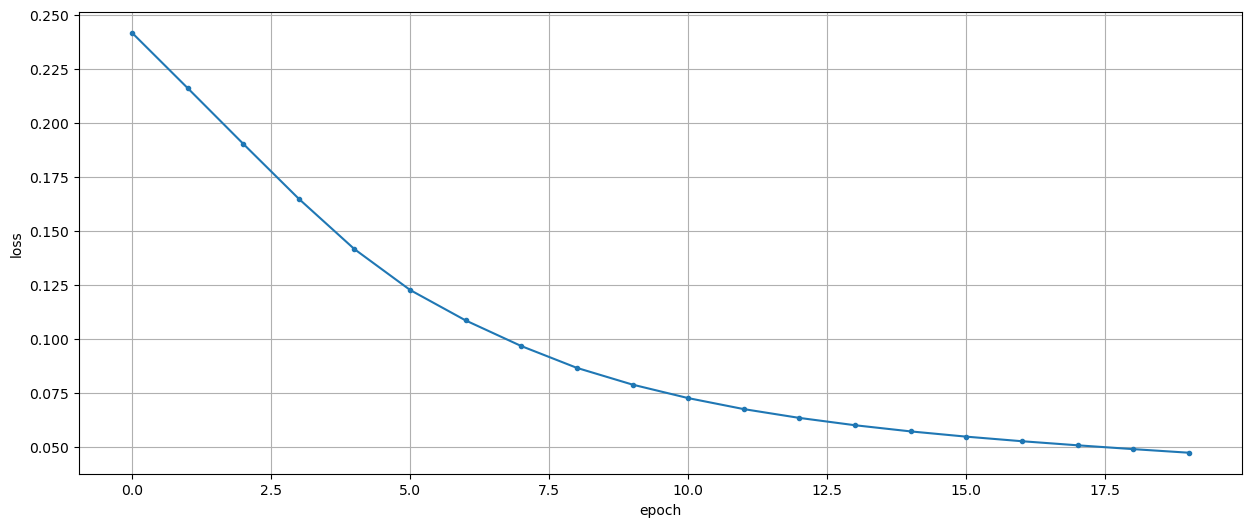

In [6]:
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[ 0.09831949 -0.13920677 -0.13791128 -0.09935729  0.15246865  0.15767036
 -0.14096814  0.14190295 -0.13448039 -0.14631817] [ 0.09831949 -0.13920677 -0.13791128 -0.09935729  0.15246865  0.15767036
 -0.14096814  0.14190295 -0.13448039 -0.14631817]


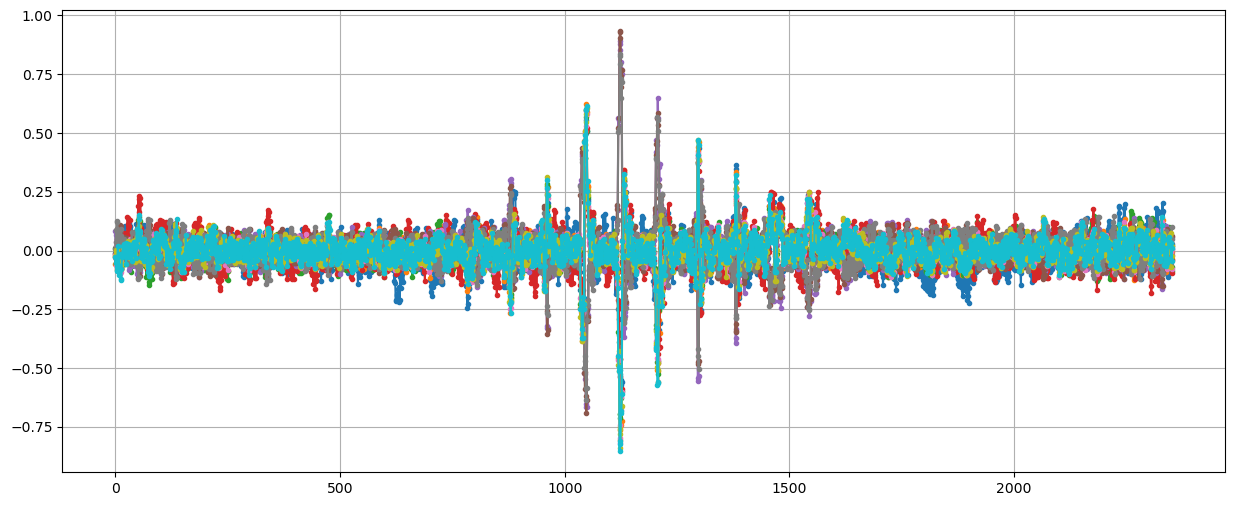

In [7]:
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step
Accuracy 0.9463087248322147


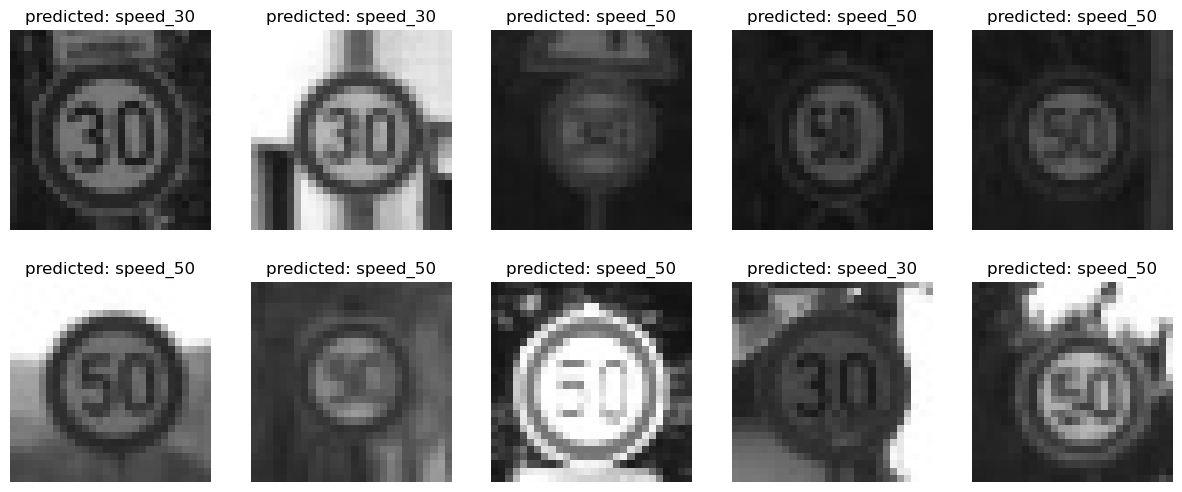

In [8]:
predictions = model.predict(flatten_images).squeeze()
predictions = ((predictions * len(class_names)) > 0.5).astype(int)
correct = 0
for prediction, label in zip(predictions, encoded_labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f"predicted: {class_names[predictions[idx]]}")
    plt.axis(False)

- There are 2250 images for each class.

- Accuracy. Strange thing. Accuracy is different each time you run the code. 
    - I guess it is because of bias? I'm tried to use bias_initializer='zeros' and kernel_initializer='zeros' to Dense initialization, but accuracy is still different each time I run the code.
    - Also I tried to set shuffle=False in model.fit, and accuracy became a constant value = 0.8129753914988814
    - Reverting initializers back the volatility.
    - Accuracy was in range 0.65 - 0.98 (randomly got 0.98 once)

- So, I've stick with shuffle=False and initializers set to zeros, and:
    - Tried to increase epochs to 20 - accuracy increased slightly, 40 epochs dropped accuracy to 0.79
    - I've added two hidden layers with 10 neurons each with relu activation - accuracy increased to 0.86.
    - I've removed one layer, and got accuracy 0.9. That is the best I could get.
    - Increasing epochs, layers, neurons give no improvement. Slightly worse results.